<a href="https://colab.research.google.com/github/Prakruthi2606/Face-Mask-Detection/blob/main/Face_Mask_Detection(MobileNetV2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Face Mask Detection using MobileNetV2**

### **1. Import libraries**

In [2]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

### **2. Load Data**

In [3]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


### **3. Create a Dataframe**

In [4]:
data_dir = os.path.join(path, "data")
print(os.listdir(data_dir))

['without_mask', 'with_mask']


In [5]:
import pandas as pd

df = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            if os.path.isfile(img_path):
                df.append([img_path, class_name])

# Create DataFrame
data = pd.DataFrame(df, columns=['img_path', 'labels'])

print(data.head())

                                            img_path        labels
0  /kaggle/input/face-mask-dataset/data/without_m...  without_mask
1  /kaggle/input/face-mask-dataset/data/without_m...  without_mask
2  /kaggle/input/face-mask-dataset/data/without_m...  without_mask
3  /kaggle/input/face-mask-dataset/data/without_m...  without_mask
4  /kaggle/input/face-mask-dataset/data/without_m...  without_mask


In [6]:
# shuffle data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [7]:
data

,img_path,labels
0,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
1,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
2,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
3,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
4,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
...,...,...
7548,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7549,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7550,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7551,/kaggle/input/face-mask-dataset/data/without_m...,without_mask


### **4. Train–Validation Split**

In [8]:
train_data, val_data = train_test_split(
    data,
    test_size=0.2,
    stratify=data['labels'],
    random_state=42
)

### **5. Data Generators**

Training Generator (with augmentation)

In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

Validation Generator (NO augmentation)

In [10]:
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [11]:
img_height, img_width = 128, 128
batch_size = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col="img_path",
    y_col="labels",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True,
    seed=42,
    color_mode='rgb'
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col="img_path",
    y_col="labels",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False,
    color_mode='rgb'
)

Found 6042 validated image filenames belonging to 2 classes.
Found 1511 validated image filenames belonging to 2 classes.


### **6. Load MobileNetV2 Base Model**

In [12]:
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze initially

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### **7. Custom Classifier**

In [13]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

### **8. Compile Model**

In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### **9. Train (Initial Training)**

In [15]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
153/189 ━━━━━━━━━━━━━━━━━━━━ 17s 474ms/step - accuracy: 0.8191 - loss: 0.3849

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 111s 561ms/step - accuracy: 0.9257 - loss: 0.1939 - val_accuracy: 0.9835 - val_loss: 0.0549
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 87s 462ms/step - accuracy: 0.9778 - loss: 0.0690 - val_accuracy: 0.9881 - val_loss: 0.0373
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 81s 427ms/step - accuracy: 0.9791 - loss: 0.0569 - val_accuracy: 0.9887 - val_loss: 0.0322
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 81s 427ms/step - accuracy: 0.9838 - loss: 0.0450 - val_accuracy: 0.9907 - val_loss: 0.0279
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 82s 434ms/step - accuracy: 0.9868 - loss: 0.0397 - val_accuracy: 0.9914 - val_loss: 0.0256
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 86s 451ms/step - accuracy: 0.9859 - loss: 0.0423 - val_accuracy: 0.9907 - val_loss: 0.0271
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 85s 451ms/step - accuracy: 0.9891 - loss: 0.0354 - val_accuracy: 0.9914 - val_loss: 0.0261
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 82s 435ms/step - accuracy: 0.9897 - loss: 0.0339 - va

### **10. Evaluation**

In [23]:
from sklearn.metrics import confusion_matrix

# Get predictions
preds = model.predict(validation_generator)
y_pred = (preds > 0.5).astype(int).flatten()

# True labels
y_true = validation_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

39/48 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step
Confusion Matrix:
 [[740   5]
 [  7 759]]


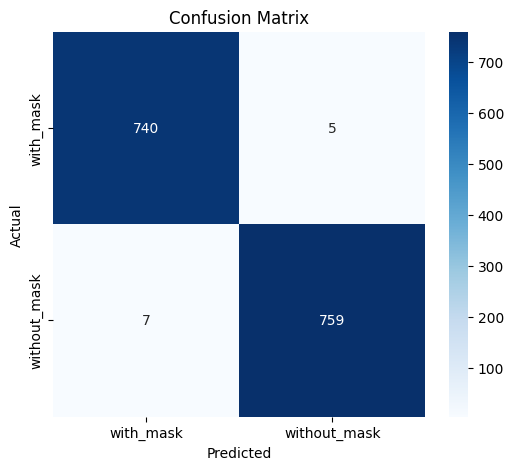

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['with_mask','without_mask']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
# classification report
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   with_mask       0.99      0.99      0.99       745
without_mask       0.99      0.99      0.99       766

    accuracy                           0.99      1511
   macro avg       0.99      0.99      0.99      1511
weighted avg       0.99      0.99      0.99      1511



### **11. Predictions**

In [26]:
train_generator.class_indices

{'with_mask': 0, 'without_mask': 1}

In [27]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

def predict_mask(img_path, model):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred = model.predict(img_array)[0][0]
    return pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


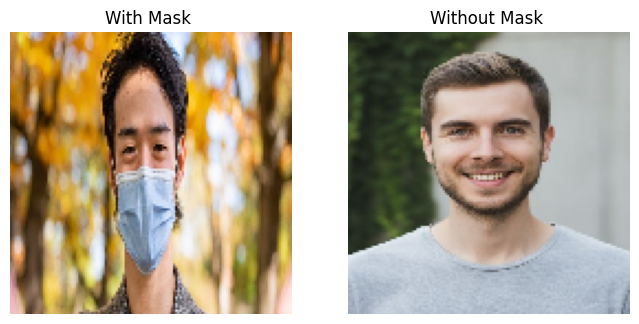

In [28]:
import matplotlib.pyplot as plt

img_list = ["mask.jpg", "no_mask.jpg"]

plt.figure(figsize=(8,4))

for i, img_path in enumerate(img_list):
    pred = predict_mask(img_path, model)
    label = "Without Mask " if pred > 0.5 else "With Mask "

    img = image.load_img(img_path, target_size=(128,128))

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.show()

### **Save the model**

In [29]:
model.save("face_mask_model.keras")